In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import numpy as np
import re

In [2]:
df_raw = pd.read_csv("agreement_scores.csv")
df_raw

,Participant ID,Apartment,Break Room,Factory,Order of worlds,Overall Satisfaction,Remarks
0,P1,AS2 : 6\nAH : 5,BS1 : 6 \nBH : 7,FS1 : 5\nFH : 6,F-B-A,6,False positives (-) \n\nJanky Controls (-)
1,P2,AS2 : 4\nAH : 4,BS1 : 6\nBH : 4,FS2 :3\nFH : 5,B-A-F,4,False positives (-)\n\nGoals (+)\n\nFactory : ...
2,P3,AS2: 6\nAH : 7,BS1: 3\nBH : 7,FS2 : 7\nFH : 7,B-F-A,6,False positives (-)
3,P4,AS1:7 \nAH :7,BS2: 4\nBH :7,FS1:7\nFH : 5,F-A-B,6,Discontinuity (-)
4,P6,AS2: 6\nAH: 6,BS1: 7\nBH: 7,FS2: 6\nFH: 6,A-B-F,7,Not accurate for a goal (-)\n\nControls (-)\n\...
5,P7,AS2 : 7\nAH : 6,BS1 : 7\nBH : 7,FS1 : 7\nFH : 7,B-F-A,6,False Positive (-\n\nNon-intuitive


In [3]:
def extract_scores_by_prefix(cell, world_prefix):
    """
    world_prefix: 'A', 'B', or 'F'
    Returns: (specific, high)
    """
    if pd.isna(cell):
        return None, None

    cell = str(cell)

    # High-level score (AH, BH, FH)
    h_match = re.search(fr'{world_prefix}H\s*:\s*(\d+)', cell)
    high = int(h_match.group(1)) if h_match else None

    # Specific score (AS1/AS2, BS1/BS2, FS1/FS2)
    s_match = re.search(fr'{world_prefix}S\d+\s*:\s*(\d+)', cell)
    specific = int(s_match.group(1)) if s_match else None

    return specific, high

In [4]:
df_parsed = df_raw.copy()

df_parsed[["Apartment_Specific","Apartment_High_Level"]] = (
    df_parsed["Apartment"]
    .apply(lambda x: pd.Series(extract_scores_by_prefix(x, "A")))
)

df_parsed[["Breakroom_Specific","Breakroom_High_Level"]] = (
    df_parsed["Break Room"]
    .apply(lambda x: pd.Series(extract_scores_by_prefix(x, "B")))
)

df_parsed[["Factory_Specific","Factory_High_Level"]] = (
    df_parsed["Factory"]
    .apply(lambda x: pd.Series(extract_scores_by_prefix(x, "F")))
)

# Dropping columns Apartment, Break Room and Factory
df_parsed = df_parsed.drop(columns=["Apartment", "Break Room", "Factory"])
df_parsed

,Participant ID,Order of worlds,Overall Satisfaction,Remarks,Apartment_Specific,Apartment_High_Level,Breakroom_Specific,Breakroom_High_Level,Factory_Specific,Factory_High_Level
0,P1,F-B-A,6,False positives (-) \n\nJanky Controls (-),6,5,6,7,5,6
1,P2,B-A-F,4,False positives (-)\n\nGoals (+)\n\nFactory : ...,4,4,6,4,3,5
2,P3,B-F-A,6,False positives (-),6,7,3,7,7,7
3,P4,F-A-B,6,Discontinuity (-),7,7,4,7,7,5
4,P6,A-B-F,7,Not accurate for a goal (-)\n\nControls (-)\n\...,6,6,7,7,6,6
5,P7,B-F-A,6,False Positive (-\n\nNon-intuitive,7,6,7,7,7,7


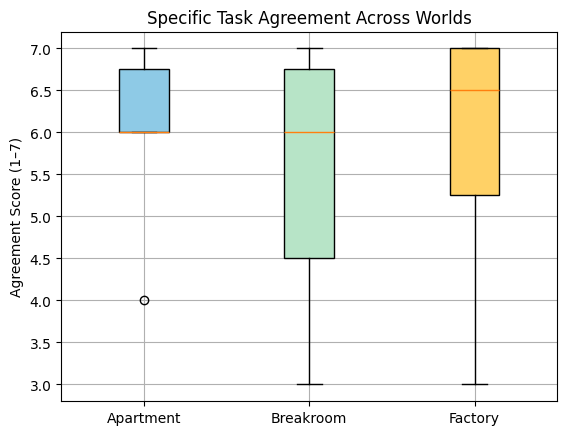

In [8]:
# Plotting box plots for Specific task agreement scores
specific_task_data = [
    df_parsed["Apartment_Specific"],
    df_parsed["Breakroom_Specific"],
    df_parsed["Factory_Specific"],
]

colors = ["#8ecae6", "#b7e4c7", "#ffd166"]

plt.figure()
bp = plt.boxplot(specific_task_data, patch_artist=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

plt.xticks([1, 2, 3], ["Apartment", "Breakroom", "Factory"])
plt.ylabel("Agreement Score (1–7)")
plt.title("Specific Task Agreement Across Worlds")
plt.grid(True)
plt.show()


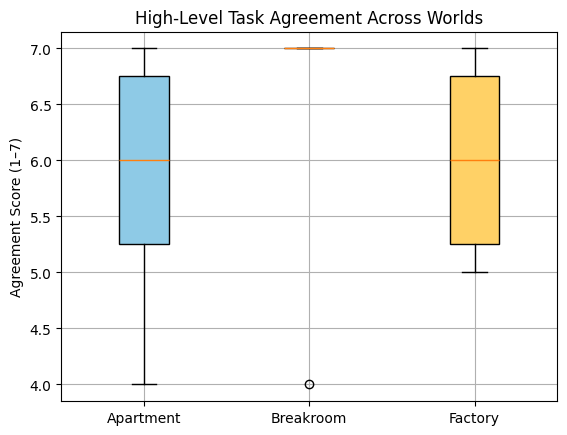

In [6]:
# Plotting box plots for High-level task agreement scores
high_level_task_data = [
    df_parsed["Apartment_High_Level"],
    df_parsed["Breakroom_High_Level"],
    df_parsed["Factory_High_Level"],
]

plt.figure()
bp = plt.boxplot(high_level_task_data, patch_artist=True)


for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

plt.xticks([1, 2, 3], ["Apartment", "Breakroom", "Factory"])
plt.ylabel("Agreement Score (1–7)")
plt.title("High-Level Task Agreement Across Worlds")
plt.grid(True)
plt.show()

In [7]:
neutral = 4

conditions = {
    "Apartment High": df_parsed["Apartment_High_Level"],
    "Apartment Specific": df_parsed["Apartment_Specific"],
    "Breakroom High": df_parsed["Breakroom_High_Level"],
    "Breakroom Specific": df_parsed["Breakroom_Specific"],
    "Factory High": df_parsed["Factory_High_Level"],
    "Factory Specific": df_parsed["Factory_Specific"],
}

for name, data in conditions.items():
    data_clean = data.dropna()

    if len(data_clean) < 2:
        print(f"{name}: Not enough data to test")
        continue

    stat, p = wilcoxon(data_clean - neutral)

    print(f"{name}")
    print(f"  n = {len(data_clean)}")
    print(f"  median = {np.median(data_clean)}")
    print(f"  p-value vs neutral (4) = {p:.4f}\n")

Apartment High
  n = 6
  median = 6.0
  p-value vs neutral (4) = 0.0625

Apartment Specific
  n = 6
  median = 6.0
  p-value vs neutral (4) = 0.0625

Breakroom High
  n = 6
  median = 7.0
  p-value vs neutral (4) = 0.0625

Breakroom Specific
  n = 6
  median = 6.0
  p-value vs neutral (4) = 0.1250

Factory High
  n = 6
  median = 6.0
  p-value vs neutral (4) = 0.0312

Factory Specific
  n = 6
  median = 6.5
  p-value vs neutral (4) = 0.0938

